#### **모두를 위한 딥러닝**
slide
https://drive.google.com/drive/folders/1qVcF8-tx9LexdDT-IY6qOnHc8ekDoL03

git
https://github.com/deeplearningzerotoall/PyTorch?tab=readme-ov-file

youtube
https://www.youtube.com/watch?v=7eldOrjQVi0&list=PLQ28Nx3M4JrhkqBVIXg-i5_CVVoS1UzAv

```bash
docker run --gpus all -it --name pt -p 8888:8888 -p 8097:8097 deeplearningzerotoall/pytorch /bin/bash
```


---

### **RNN (Recurrent Neural Network)**

- 시계열 데이터나 자연어처럼 순서가 중요한 데이터를 다룰 때 핵심적인 모델
- 특징
    - hidden state : 네트어크가 이전 단계에서 얻은 정보를 저장하는 메모리 역할을 함
    - 순차적 처리 : 첫번째 단어의 정보를 두번째 단어로, 두번째 단어를.. 이런식으로 전체 맥락을 파악함
    - 문장의 길이에 상관없이 데이터 처리 가능
- 단점
    - long-term dependency
    - gradient vanishing/exploding

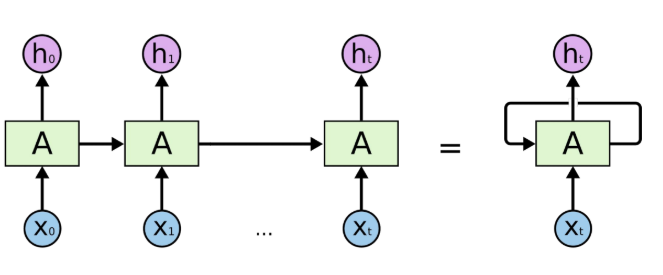

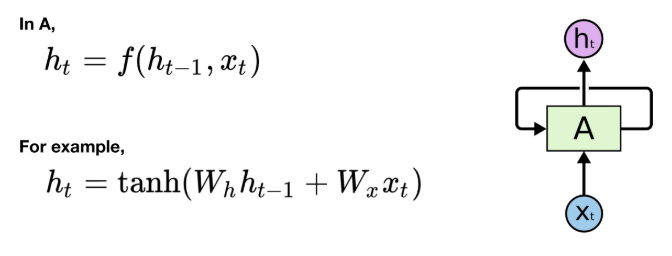

In [15]:
from IPython.display import Image, display
display(Image(filename='images/6.png', embed=True))
display(Image(filename='images/7.png', embed=True))

- A에서는 현재 단계 이전의 hidden state: $h_{t-1}$와 지금 단계에서의 입력값 $x_t$로 $h_t$를 출력한다

input or Output shape = (a,b, c)

- a = Batch size
- b = sequence length (pytorch 자동)
- c = Hidden state(=output) or Input size

In [ ]:
import torch
import numpy as np
torch.manual_seed(0)

# declare dimension
input_size = 4
hidden_size = 2


# singleton example
# shape : (1, 1, 4)
# input_data_np = np.array([[[1, 0, 0, 0]]])

# sequential example (one-hot encoding vector)
# input data shape : (3, 5, 4)
# batch 3 (한번에 3개문장 처리), sequence length 5 (문장의 알파벳 개수), input size 4 (각 단어의 표현 숫자)
h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]
input_data_np = np.array([[h, e, l, l, o], [e, o, l, l, l], [l, l, e, e, l]], dtype=np.float32)

In [2]:
# transform as torch tensor
input_data = torch.Tensor(input_data_np)

# declare RNN
rnn = torch.nn.RNN(input_size, hidden_size)

In [ ]:
# check output
outputs, _status = rnn(input_data)
print(outputs)
print(outputs.size()) # shape : [3, 5, 2]
# 3: 배치 크기 유지.
# 5: 각 시점(단어)별로 계산된 결과가 모두 저장됨.
# 2: 설정한 hidden_size만큼의 특징 값으로 압축됨.

# 즉, 4차원의 one-hot encoding vector가 RNN레이어를 
# 거치며 2차원의 hidden state로 변환됨

tensor([[[-0.7497, -0.6135],
         [-0.5282, -0.2473],
         [-0.9136, -0.4269],
         [-0.9136, -0.4269],
         [-0.9028,  0.1180]],

        [[-0.5753, -0.0070],
         [-0.9052,  0.2597],
         [-0.9173, -0.1989],
         [-0.9173, -0.1989],
         [-0.8996, -0.2725]],

        [[-0.9077, -0.3205],
         [-0.8944, -0.2902],
         [-0.5134, -0.0288],
         [-0.5134, -0.0288],
         [-0.9127, -0.2222]]], grad_fn=<StackBackward0>)
torch.Size([3, 5, 2])


**출력 결과를 정리하자면**  <br>

tensor([[[-0.7497, -0.6135], # H <br>
         [-0.5282, -0.2473],  # E <br>
         [-0.9136, -0.4269],    # L <br>
         [-0.9136, -0.4269],    # L <br>
         [-0.9028,  0.1180]],   # O <br>
 <br>
torch.Size([3, 5, 2]) <br>

---

### **hihi i love u 예측 모델 만들어보기**

In [12]:
sample = " hihi i love u"

# make dictionary
char_set = list(set(sample))
char_dic = {c: i for i, c in enumerate(char_set)}
print(char_dic)

{'e': 0, 'h': 1, 'v': 2, 'u': 3, 'l': 4, 'o': 5, ' ': 6, 'i': 7}


In [13]:
# hyper parameters
dic_size = len(char_dic) # 8
hidden_size = len(char_dic) # 8
learning_rate = 0.1

print(len(char_dic))

8


In [15]:
import torch
import torch.optim as optim
import numpy as np

# data setting
sample_idx = [char_dic[c] for c in sample] # 각 문자열을 index 리스트로 변환
x_data = [sample_idx[:-1]]  # 마지막 글자를 제외
x_one_hot = [np.eye(dic_size)[x] for x in x_data] # one hot encoding
y_data = [sample_idx[1:]] # 첫번째 글자를 제외

# transform as torch tensor variable
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

# declare RNN
rnn = torch.nn.RNN(dic_size, hidden_size, batch_first=True) # dic_size&hidden_size= 8

# loss & optimizer setting
criterion = torch.nn.CrossEntropyLoss() # softmax + CE
optimizer = optim.Adam(rnn.parameters(), learning_rate)

In [16]:
# start training
for i in range(100):
    optimizer.zero_grad()
    outputs, _status = rnn(X)
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    result = outputs.data.numpy().argmax(axis=2)
    result_str = ''.join([char_set[c] for c in np.squeeze(result)])
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

0 loss:  2.1316022872924805 prediction:  [[4 1 1 4 1 4 1 4 1 4 1 2 1]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  lhhlhlhlhlhvh
1 loss:  1.8122509717941284 prediction:  [[7 7 5 7 5 7 5 7 5 1 1 5 7]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  iioioioiohhoi
2 loss:  1.6407192945480347 prediction:  [[7 7 7 7 5 7 5 7 5 7 0 6 7]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  iiiioioioie i
3 loss:  1.4896771907806396 prediction:  [[7 7 6 7 6 7 6 7 5 7 0 6 7]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  ii i i ioie i
4 loss:  1.3722741603851318 prediction:  [[1 7 6 7 6 7 6 7 5 7 0 6 7]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  hi i i ioie i
5 loss:  1.2951772212982178 prediction:  [[1 7 1 7 6 7 6 7 5 2 1 6 3]] true Y:  [[1, 7, 1, 7, 6, 7, 6, 4, 5, 2, 0, 6, 3]] prediction str:  hihi i iovh u
6 loss:  1.2375534772872925 prediction:  [[1 7 1 7 6 7 6 7 5 2 1 6 3]] true Y:  [[